# Week 2 — Notebook 3: Comparative Analysis (Bonus)

This notebook contains analysis questions that require you to **write code and explain your findings**.

For each question:
1. Write your code in the empty cell below the question
2. Add a short written answer (2–4 sentences) in a markdown cell after your output

You may load processed CSVs from `data/processed/` or recompute indicators directly from `data/raw/`.

> Charts must have titles, axis labels, and legends. Written answers must reference specific dates or numbers from your output.

---

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

def safe_symbol(s):
    return s.replace('^','').replace('.',  '_').replace('=','_').replace('-','_')

def load_features(symbol):
    return pd.read_csv(PROCESSED_DIR / f'{safe_symbol(symbol)}_features.csv',
                       parse_dates=['date'], index_col='date')

print('Setup done.')

Setup done.


---

## Q1 — Which US stock had the highest average SMA-20 over 2020–2024?

Load the processed features for `AAPL`, `MSFT`, `NVDA`, `TSLA`, and `SPY`.
Filter to **2020-01-01 → 2024-12-31**.
For each symbol, compute the mean of its `sma_ratio_20` over that period (not the raw SMA value — the ratio tells you how far above/below average each stock typically trades).
Display results as a **horizontal bar chart**, sorted from highest to lowest.

**Answer in a markdown cell:** Which stock was most consistently above its 20-day average? What does a persistently positive sma_ratio suggest about its trend?

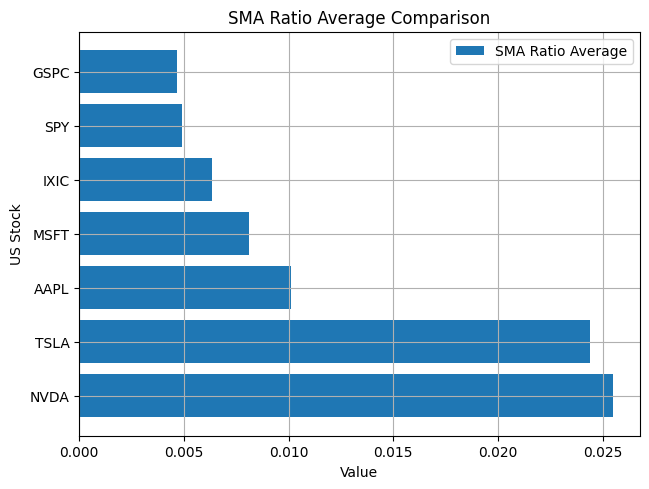

In [ ]:
# Your code here
us={}
for sym in ["GSPC", "IXIC", "SPY", "AAPL", "MSFT", "NVDA", "TSLA"]:
    df=pd.read_csv(PROCESSED_DIR/f'{sym}_features.csv')
    df['date']=pd.to_datetime(df['date'])
    df.set_index('date',inplace=True)
    df=df[(df.index>='2020-01-01')&(df.index<='2024-12-31')]
    us[f'{sym}']=float(df['sma_ratio_20'].mean())
us =pd.Series(us)
us = us.sort_values(ascending=False)
plt.barh(us.index,us.values, label='SMA Ratio Average')
plt.title('SMA Ratio Average Comparison')
plt.legend()
plt.grid()
plt.tight_layout()
plt.xlabel('Value')
plt.ylabel("US Stock")
plt.show()


*Your written answer here.*

---

## Q2 — Side-by-side RSI comparison: one Indian stock, one US stock, one crypto

Choose one symbol from each group:
- India: `RELIANCE.NS` or `TCS.NS`
- US: `AAPL`, `MSFT`, or `NVDA`
- Crypto: `BTC-USD` or `ETH-USD`

Plot their `rsi_14` in a **3-row subplot** sharing the x-axis, covering the most recent **two full years** of data.
Draw dashed lines at 0.70 (overbought) and 0.30 (oversold) on each panel.

**Answer in a markdown cell:** Which asset class spends the most time in extreme RSI territory (above 0.70 or below 0.30)? Give a possible reason.

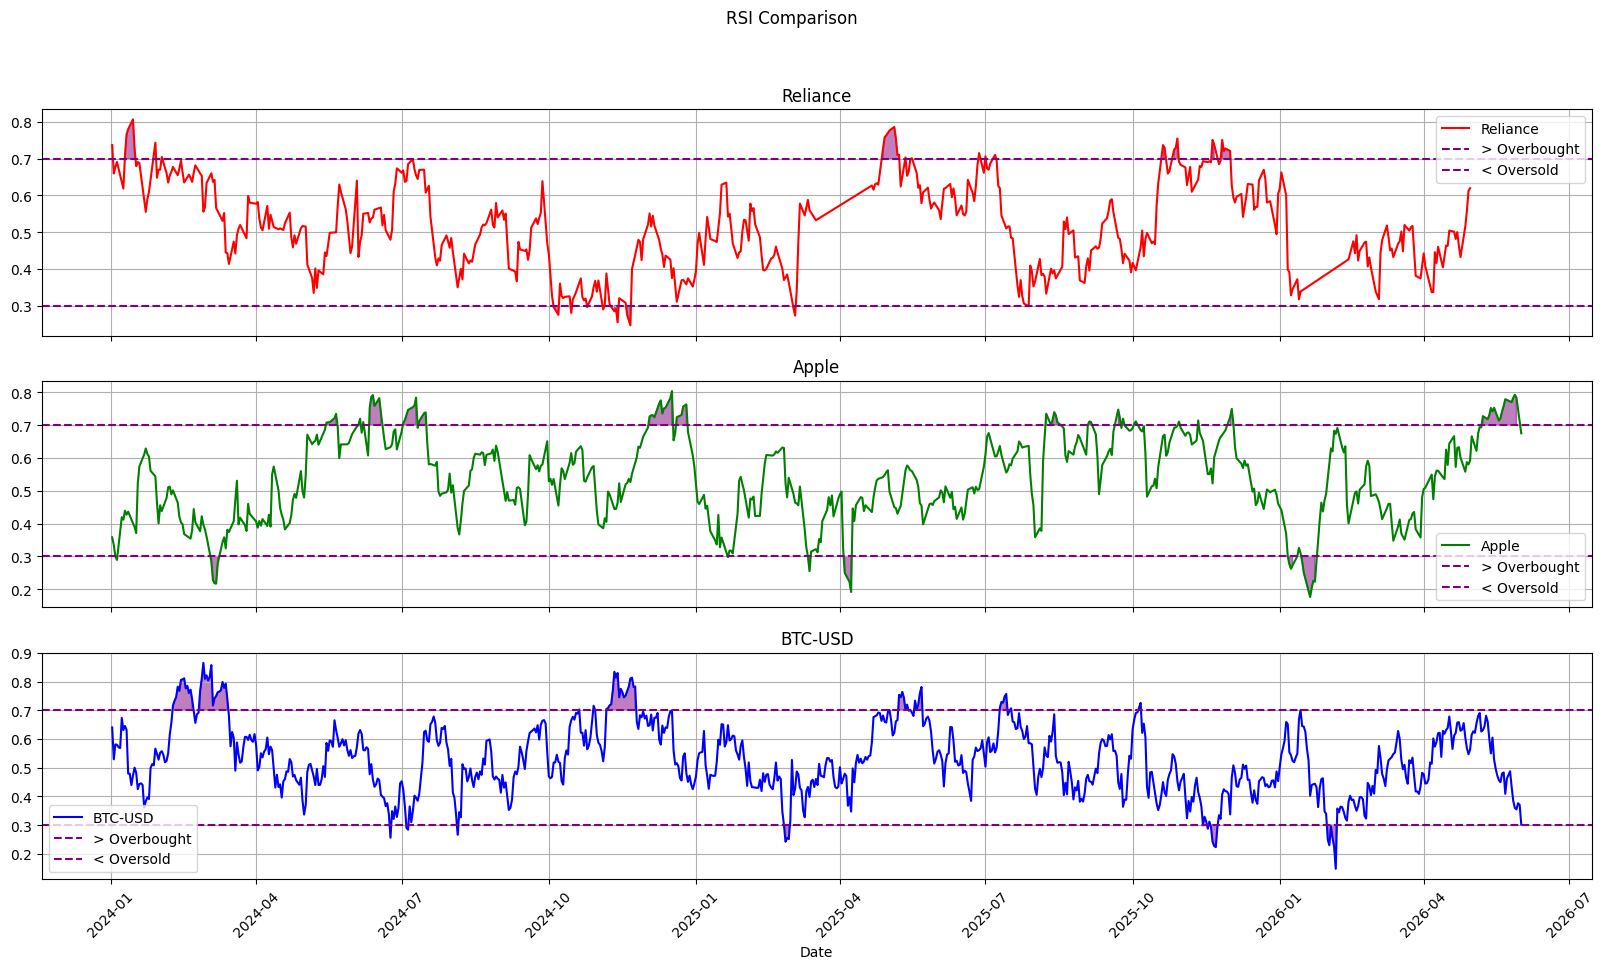

In [ ]:
# Your code here
reliance=pd.read_csv(PROCESSED_DIR/'RELIANCE_NS_features.csv')
aaple=pd.read_csv(PROCESSED_DIR/'AAPL_features.csv')
btc=pd.read_csv(PROCESSED_DIR/'BTC_USD_features.csv')
reliance['date']=pd.to_datetime(reliance['date'])
reliance.set_index(reliance['date'],inplace=True)
aaple['date']=pd.to_datetime(aaple['date'])
aaple.set_index(aaple['date'],inplace=True)
btc['date']=pd.to_datetime(btc['date'])
btc.set_index(btc['date'],inplace=True)
reliance=reliance[reliance.index >'2024-01-01']
aaple=aaple[aaple.index > '2024-01-01']
btc=btc[btc.index> '2024-01-01']
fig, (ax1,ax2,ax3) =plt.subplots(3,1,sharex=True,figsize=(20,10))
ax1.plot(reliance.index,reliance['rsi_14'],label='Reliance',color='red')
ax1.axhline(0.7, linestyle='--',color='purple', label='> Overbought')
ax1.axhline(0.3, linestyle='--',color='purple', label='< Oversold')
ax1.fill_between(reliance.index, 0.7, reliance['rsi_14'], where=(reliance['rsi_14']>0.7),color='purple',alpha=0.5)
ax1.fill_between(reliance.index,reliance['rsi_14'], 0.3,where=(reliance['rsi_14']<0.3),color='purple',alpha=0.5)
ax1.set_title('Reliance')
ax1.grid()
ax1.legend()
ax2.plot(aaple.index,aaple['rsi_14'],label='Apple',color='green')
ax2.axhline(0.7, linestyle='--',color='purple', label='> Overbought')
ax2.axhline(0.3, linestyle='--',color='purple', label='< Oversold')
ax2.fill_between(aaple.index, 0.7, aaple['rsi_14'], where=(aaple['rsi_14']>0.7),color='purple',alpha=0.5)
ax2.fill_between(aaple.index, aaple['rsi_14'], 0.3,where=(aaple['rsi_14']<0.3),color='purple',alpha=0.5)
ax2.set_title('Apple')
ax2.grid()
ax2.legend()
ax3.plot(btc.index,btc['rsi_14'],label='BTC-USD',color='blue')
ax3.axhline(0.7, linestyle='--',color='purple', label='> Overbought')
ax3.axhline(0.3, linestyle='--',color='purple', label='< Oversold')
ax3.fill_between(btc.index, 0.7, btc['rsi_14'], where=(btc['rsi_14']>0.7),color='purple',alpha=0.5)
ax3.fill_between(btc.index, btc['rsi_14'], 0.3,where=(btc['rsi_14']<0.3),color='purple',alpha=0.5)
ax3.set_title('BTC-USD')
ax3.grid()
ax3.legend()
plt.xlabel('Date')
plt.suptitle('RSI Comparison')
plt.xticks(rotation=45)
plt.show()

*Your written answer here.*

---

## Q3 — MACD histogram comparison: AAPL vs MSFT vs NVDA

Plot the `macd_hist` column for all three symbols in a **3-row subplot** (shared x-axis, last two years).
Colour bars **green** when positive and **red** when negative so crossovers are visually clear.

Then count the number of histogram sign changes per symbol (i.e. how often does the bar switch from positive to negative or vice versa?).

**Answer in a markdown cell:** Which stock has the most sign changes? What does frequent sign-changing imply about that stock's trend consistency?

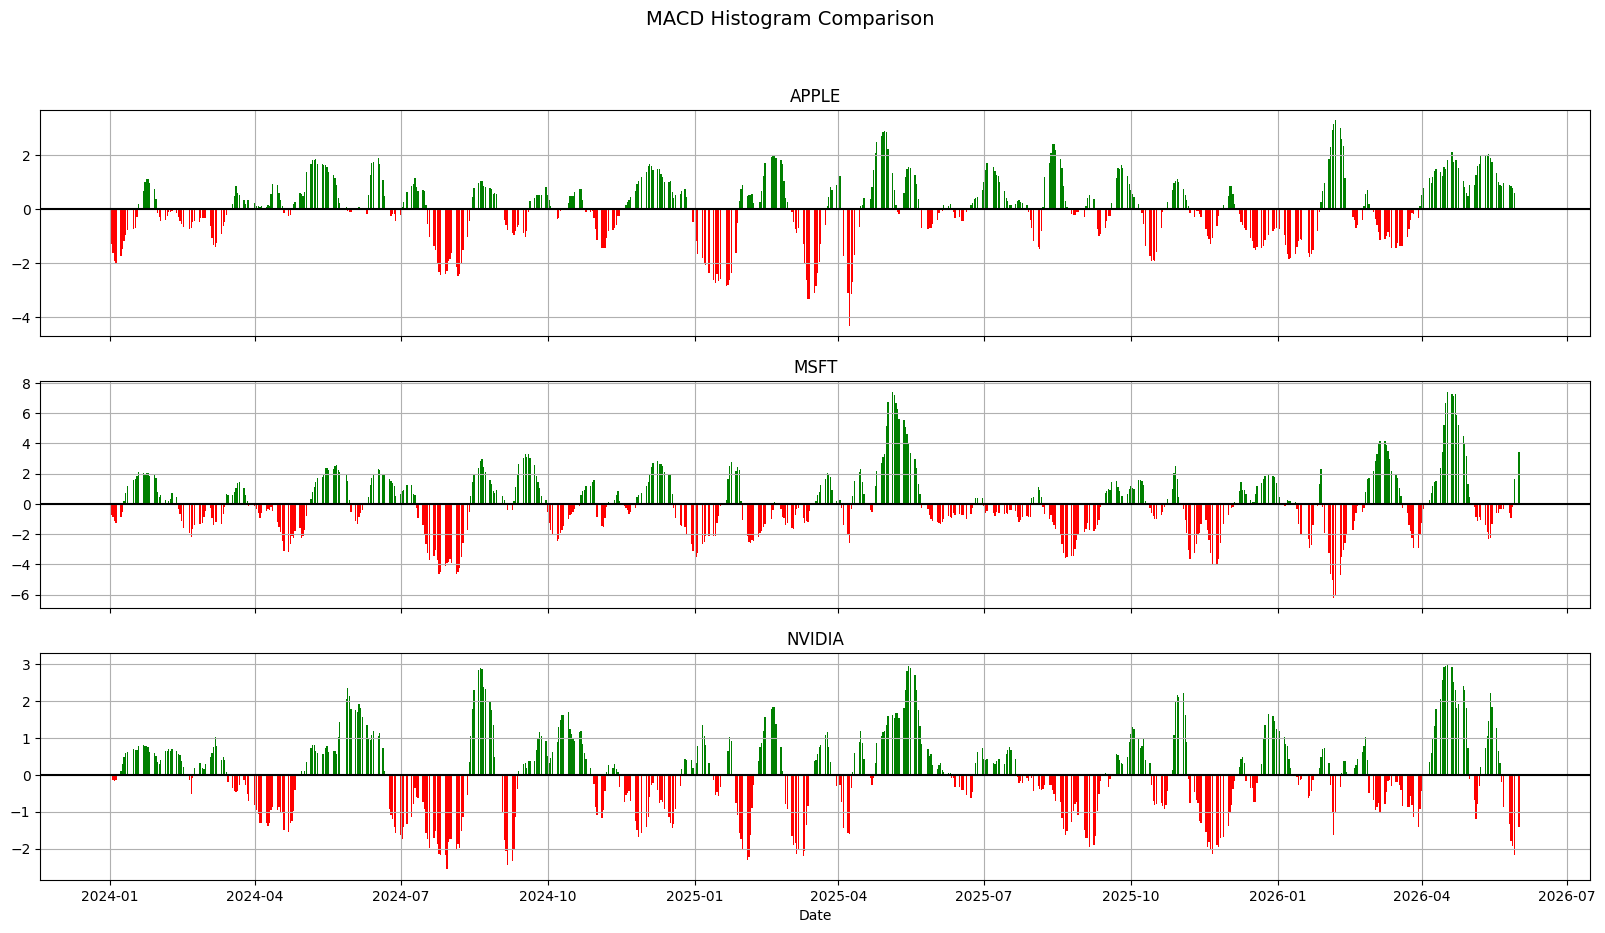

{'APPLE': 49, 'MSFT': 49, 'NVDA': 46}


In [ ]:
# Your code here
msft=pd.read_csv(PROCESSED_DIR/'MSFT_features.csv')
aaple=pd.read_csv(PROCESSED_DIR/'AAPL_features.csv')
nvda=pd.read_csv(PROCESSED_DIR/'NVDA_features.csv')
msft['date']=pd.to_datetime(msft['date'])
msft.set_index(msft['date'],inplace=True)
aaple['date']=pd.to_datetime(aaple['date'])
aaple.set_index(aaple['date'],inplace=True)
nvda['date']=pd.to_datetime(nvda['date'])
nvda.set_index(nvda['date'],inplace=True)
msft=msft[msft.index >'2024-01-01']
aaple=aaple[aaple.index > '2024-01-01']
nvda=nvda[nvda.index> '2024-01-01']
fig, (ax1,ax2,ax3) =plt.subplots(3,1,sharex=True,figsize=(20,10))
ax1.bar(aaple.index,aaple['macd_hist'], color=['green' if v>0 else 'red' for v in aaple['macd_hist']])
ax1.axhline(0.0 ,color ='black',linewidth='1.5')
ax1.set_title('APPLE')
ax1.grid()
ax2.bar(msft.index,msft['macd_hist'], color=['green' if v>0 else 'red' for v in msft['macd_hist']])
ax2.axhline(0.0 ,color ='black',linewidth='1.5')
ax2.set_title('MSFT')
ax2.grid()
ax3.bar(nvda.index,nvda['macd_hist'], color=['green' if v>0 else 'red' for v in nvda['macd_hist']])
ax3.axhline(0.0 ,color ='black',linewidth='1.5')
ax3.set_title('NVIDIA')
ax3.grid()
plt.suptitle('MACD Histogram Comparison', fontsize=14)
plt.xlabel('Date')
plt.show()
sign_change={}
count=aaple['macd_hist'][((aaple['macd_hist']>0) & (aaple['macd_hist'].shift(1)<0)) | ((aaple['macd_hist']<0) & (aaple['macd_hist'].shift(1)>0))]
sign_change['APPLE']=count.shape[0]
count=msft['macd_hist'][((msft['macd_hist']>0) & (msft['macd_hist'].shift(1)<0)) | ((msft['macd_hist']<0) & (msft['macd_hist'].shift(1)>0))]
sign_change['MSFT']=count.shape[0]
count=nvda['macd_hist'][((nvda['macd_hist']>0) & (nvda['macd_hist'].shift(1)<0)) | ((nvda['macd_hist']<0) & (nvda['macd_hist'].shift(1)>0))]
sign_change['NVDA']=count.shape[0]
print(sign_change)

*Your written answer here.*

---

## Q4 — Volatility comparison: which symbol has the widest Bollinger Bands on average?

Load processed features for at least **six symbols** spanning at least two markets.
Compute the **mean `bb_width`** for each symbol over its full available history.
Plot as a sorted bar chart.

Then for the **most volatile symbol**, plot its close price with Bollinger Bands and highlight the top-10% widest-band periods with a shaded background.

**Answer in a markdown cell:** What event or characteristic of that asset explains why its bands are wider than the others?

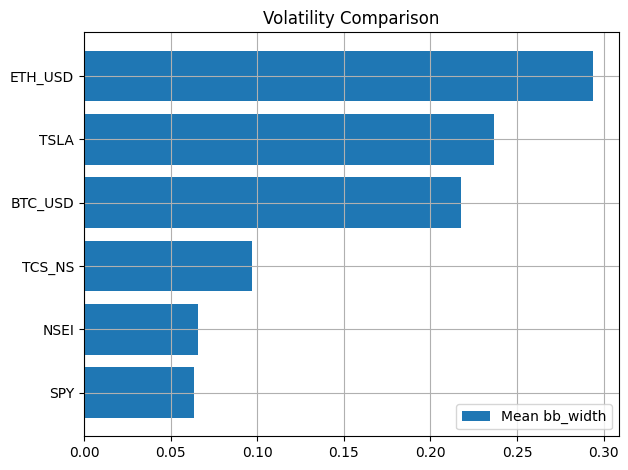

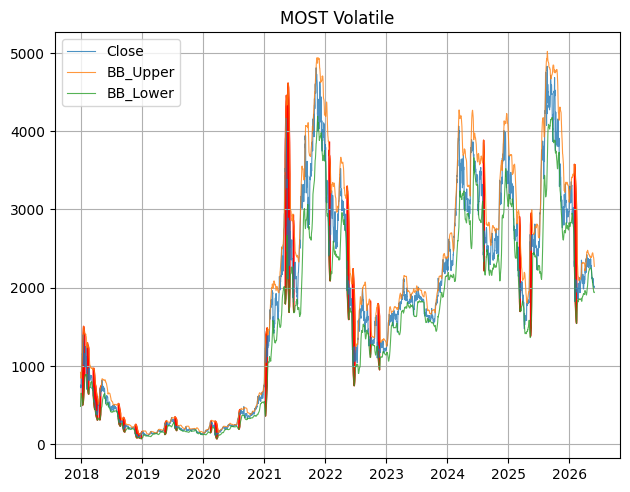

In [ ]:
# Your code here
NSEI=pd.read_csv(PROCESSED_DIR/"NSEI_features.csv")
TCS_NS=pd.read_csv(PROCESSED_DIR/"TCS_NS_features.csv")
SPY=pd.read_csv(PROCESSED_DIR/"SPY_features.csv")
TSLA=pd.read_csv(PROCESSED_DIR/"TSLA_features.csv")
BTC_USD=pd.read_csv(PROCESSED_DIR/"BTC_USD_features.csv")
ETH_USD=pd.read_csv(PROCESSED_DIR/"ETH_USD_features.csv")
avg={}
avg['NSEI']=float(NSEI['bb_width'].mean())
avg['TCS_NS']=float(TCS_NS['bb_width'].mean())
avg['SPY']=float(SPY['bb_width'].mean())
avg['TSLA']=float(TSLA['bb_width'].mean())
avg['BTC_USD']=float(BTC_USD['bb_width'].mean())
avg['ETH_USD']=float(ETH_USD['bb_width'].mean())
avg=pd.Series(avg)
avg=avg.sort_values()
plt.barh(avg.index,avg.values,label='Mean bb_width')
plt.title('Volatility Comparison')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()
ETH_USD['date']=pd.to_datetime(ETH_USD['date'])
ETH_USD.set_index('date',inplace=True)
threshold=ETH_USD['bb_width'].quantile(0.9)
plt.plot(ETH_USD.index,ETH_USD['close'],label='Close',alpha=0.8,linewidth=0.8)
plt.plot(ETH_USD.index,ETH_USD['bb_upper'],label='BB_Upper',alpha=0.8,linewidth=0.8)
plt.plot(ETH_USD.index,ETH_USD['bb_lower'],label='BB_Lower',alpha=0.8,linewidth=0.8)
plt.fill_between(ETH_USD.index,ETH_USD['bb_lower'],ETH_USD['bb_upper'],where=ETH_USD['bb_width']>threshold,color='red')
plt.grid();plt.legend();plt.tight_layout();plt.title('MOST Volatile');plt.show()

*Your written answer here.*

---

## Q5 — Why was RSI elevated? (Three companies, written analysis)

Choose **three companies** — one from each market group (India / US / Crypto).

For each company, find the **longest consecutive streak of days with `rsi_14` > 0.65**.
Report: start date, end date, streak length in days, and the price gain (%) during that streak.

For each company, write **at least 3 sentences** explaining what likely drove the sustained momentum. Consider: earnings releases, macro tailwinds, sector rotation, or broader market risk-on periods. Use the dates you found to anchor your reasoning.

Plot the price and RSI together for each company, with the identified streak highlighted.

In [ ]:
# Your code here — find longest overbought streak per company


*Company A (India) — written answer:*

*Company B (US) — written answer:*

*Company C (Crypto) — written answer:*

---

## Q6 — Why was ATR ratio highest in that month? (Three companies)

Using the same three companies from Q5:

For each company, find the **calendar month with the highest mean `atr_ratio`**.
Plot the daily `atr_ratio` for the full year containing that month, with the peak month highlighted using `fill_between` or `axvspan`.

Write **at least 3 sentences per company** explaining the spike. Consider: earnings surprises, central bank decisions, geopolitical events, or crypto-specific catalysts. ATR captures both intraday swings and overnight gap risk — comment on which you think dominated.

In [ ]:
# Your code here


*Company A — written answer:*

*Company B — written answer:*

*Company C — written answer:*

---

## Q7 — Does a high Stochastic %K always mean the stock is overbought?

Compute the fraction of days with `stoch_k` > 0.80 for each of your three companies.
Bar-chart the results.

Then for the company with the **highest fraction**, plot its `stoch_k` alongside `sma_ratio_50` for the last two years on a dual-panel chart.

**Answer in a markdown cell:** A high stochastic can mean (a) the stock is genuinely overbought and due for reversal, or (b) it is in a strong uptrend and keeps closing near its highs. Use the `sma_ratio_50` panel to argue which case applies here.

In [ ]:
# Your code here


*Your written answer here.*

---
